# DreemGO - Motor Predictivo y de Recomendación
### Fase de Experimentación (Semana 6/7)
Este notebook demuestra los dos pilares predictivos propuestos para el Data Product:
1. **Predicción de Viabilidad Climática:** Análisis de 10 años de series de tiempo para estimar la seguridad del viaje.
2. **Recomendación Comercial Dinámica:** Inyección de ferias y eventos temporales en base a las fechas de viaje.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style="darkgrid")

## 1. Análisis y Predicción Climática (Forecasting Espacial)

In [4]:
# Cargar datos históricos del clima
df_clima = pd.read_csv('../data/historial_clima_regiones.csv', sep=';')
df_clima['MES'] = df_clima['MES'].astype(int)
print(f"Registros climáticos cargados: {len(df_clima)}")
df_clima.head()

Registros climáticos cargados: 2880


,REGION,AÑO,MES,TEMPERATURA_MEDIA_C,PRECIPITACION_TOTAL_MM
0,AMAZONAS,2014,1,14.91,264.1
1,AMAZONAS,2014,2,14.90,366.8
2,AMAZONAS,2014,3,14.92,340.0
3,AMAZONAS,2014,4,15.11,179.8
4,AMAZONAS,2014,5,15.07,206.5


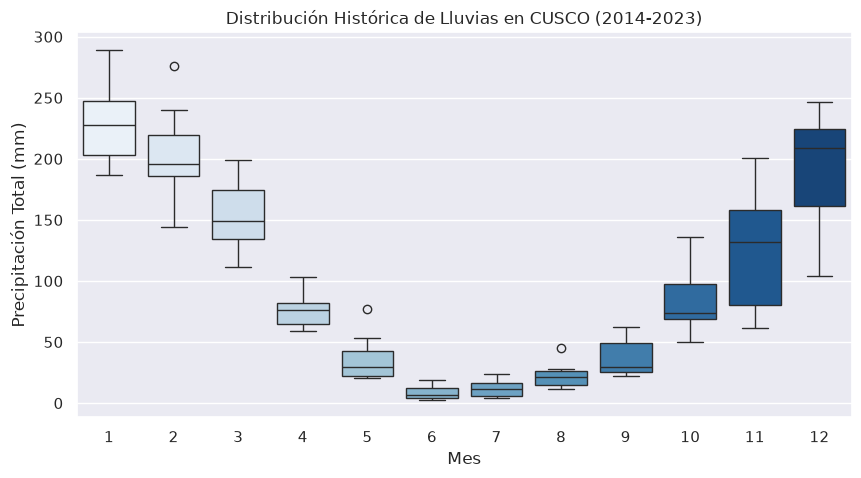

Insight: El modelo predictivo penalizará severamente los viajes en Enero, Febrero y Marzo.


In [5]:
# EDA: Comportamiento histórico de las lluvias en CUSCO (La base para predecir)
df_cusco = df_clima[df_clima['REGION'] == 'CUSCO']

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_cusco, x='MES', y='PRECIPITACION_TOTAL_MM', palette='Blues')
plt.title('Distribución Histórica de Lluvias en CUSCO (2014-2023)')
plt.ylabel('Precipitación Total (mm)')
plt.xlabel('Mes')
plt.show()

print("Insight: El modelo predictivo penalizará severamente los viajes en Enero, Febrero y Marzo.")

In [6]:
def calcular_score_viabilidad(region, mes_viaje):
    """
    Motor predictivo simplificado basado en promedios estadísticos históricos.
    Retorna un score del 0% al 100% de viabilidad para viajar.
    """
    df_filtro = df_clima[(df_clima['REGION'] == region) & (df_clima['MES'] == mes_viaje)]
    if df_filtro.empty:
        return 0
        
    precip_media = df_filtro['PRECIPITACION_TOTAL_MM'].mean()
    
    # Penalización algorítmica (Ej: >150mm es peligro extremo por huaicos)
    if precip_media > 150:
        score = 15  # Muy baja viabilidad
    elif precip_media > 80:
        score = 45
    elif precip_media > 30:
        score = 75
    else:
        score = 98  # Clima perfecto
        
    return score

# Prueba de Predicción
mes_solicitado = 2 # Febrero
region_solicitada = 'CUSCO'
score = calcular_score_viabilidad(region_solicitada, mes_solicitado)
print(f"Predicción de Viabilidad para {region_solicitada} en el mes {mes_solicitado}: {score}%")

Predicción de Viabilidad para CUSCO en el mes 2: 15%


## 2. Inyección de Comercio Local Dinámico (Recomendador B2B)

In [7]:
# Cargar ferias y eventos (El Flywheel de monetización)
df_eventos = pd.read_csv('../data/comercios_ferias_locales.csv', sep=';')
df_eventos['FECHA_INICIO'] = pd.to_datetime(df_eventos['FECHA_INICIO'])
df_eventos['FECHA_FIN'] = pd.to_datetime(df_eventos['FECHA_FIN'])
print(f"Comercios locales registrados: {len(df_eventos)}")

Comercios locales registrados: 500


In [8]:
def recomendar_eventos_locales(region, fecha_viaje_usuario):
    """
    Simula el recomendador de inyección de anuncios/eventos en la ruta del usuario.
    Filtra por cruce temporal y ordena por relevancia (CTR proxy).
    """
    fecha = pd.to_datetime(fecha_viaje_usuario)
    
    # Condición de coincidencia espacio-temporal
    eventos_activos = df_eventos[
        (df_eventos['REGION'] == region) &
        (df_eventos['FECHA_INICIO'] <= fecha) &
        (df_eventos['FECHA_FIN'] >= fecha)
    ].copy()
    
    # Ordenar por el peso de la publicidad para maximizar revenue
    recomendaciones = eventos_activos.sort_values(by='RELEVANCIA_PUBLICIDAD', ascending=False).head(3)
    return recomendaciones[['NOMBRE_EVENTO', 'CATEGORIA', 'COSTO_PEN', 'RELEVANCIA_PUBLICIDAD']]

# Simulación: Turista viaja a Cusco el 15 de Noviembre de 2024
eventos_recomendados = recomendar_eventos_locales('CUSCO', '2024-11-15')
print("Eventos Comerciales Inyectados a la Ruta:")
eventos_recomendados

Eventos Comerciales Inyectados a la Ruta:


,NOMBRE_EVENTO,CATEGORIA,COSTO_PEN,RELEVANCIA_PUBLICIDAD
128,Fiesta Patronal Andes CUSCO,Cultura,50,4
